***build a config.json file and propose commands to launch either script or sbatch  on ESRF machines***

tested when pasting command line on terminal window of jupyter-slurm

In [1]:
JUPYTER_LAB = True # False for jupyter hub or notebook

In [2]:
if not JUPYTER_LAB: # jupyterhub
    %matplotlib notebook  
else:
    %matplotlib widget 

# Third party modules
import matplotlib as mpl     # graphs and plots
import matplotlib.pyplot as plt

import time,copy,os
from pathlib import Path
import datetime

import json
import numpy as np

import multiprocessing
nbcpus_max = multiprocessing.cpu_count()
print('max number of cpus : ',nbcpus_max)  
print('number of scheduled cpus : ', len(os.sched_getaffinity(0)))

max number of cpus :  40
number of scheduled cpus :  4


In [3]:
!squeue | grep micha

          27652467 jupyter-n spawner-    micha  R       2:01      1 hpc5-1001


In [4]:
# a helper function
import re
def getfileindex(filename:str)->int:
    """
    extract integer index at the end of filename before file extension

    Parameters
    ----------
    filename
        filename or full path, str or Path object

    Returns
    -------
        file index

    Examples
    --------
    >>> getindex('/home/mdfgf.rgf/efrf_fre/img_525.5_AAA_01788.cor')
    1788
    """
    ff = Path(filename)
    fileextension = ff.suffix[1:]
    match = re.search(r'\d+\.'+fileextension, ff.name)
    val = match.group()[:-len(fileextension)]
    return int(float(val))

# Input Parameters for indexing

EXHAUSTIVE list

In [5]:
# Default OPTIONAL parameters
# for indexing a complete data set
# we don't need yet to know the dimensions of the map neither hdf5 file
mapdims = None
invmapdims = None
hdf5masterfile  = None
HDF5_LOGFILE_EXISTS = False
pathHDF5 = None
nbcpus = 40 # default value
smi = {}  # dictionary of files without results (no .fit )



In [6]:
#!ls {str(Path(maindatafolder+'/'+subfolderscandata+'//'+'img_CORfiles'))}

In [7]:
#####   Zr/Cr ###########
# Zr data set BLC15488  ech15  map2D  expo0p1sec
if 0:
    # parent folder of all dataset data (from .cor files coming from peaksearch results on images)
    maindatafolder = '/data/projects/mapgrainxl/blc15488/bm32/20240601/RAW_DATA'
    # subfolder where images .tiff are
    subfolderscandata = 'ech15/ech15_map2Dexpo0p1sec/scan0001'
    
    imagefolder = Path(maindatafolder+'/'+subfolderscandata)
    
    mainprocessed_data = '/data/projects/mapgrainxl/blc15488/bm32/20240601/PROCESSED_DATA'
    datfilefolder = str(Path(maindatafolder+'/'+subfolderscandata+'//'+'img_CORfiles_Zr_2024-09-27_10-15-23'))
    #datfilefolder = str(Path(maindatafolder+'/'+subfolderscandata+'//'+'img_CORfiles'))  # wroing start of.cor files  SCMOS_4M wrong
    corfilefolder = datfilefolder
    
    #calibration parameters file
    detfile = str(Path(maindatafolder+'/'+'Ge1/Ge1_calib_std/scan0001/Ge1.det'))
    
    # corfilefolder = str(Path(maindatafolder+'/'+subfolderscandata+'//'+'img_CORfiles'))
    prefixfilename = 'img_'
    suffix ='.cor'
    CCDLabel = 'sCMOS'
    sizeofzeropadding = 4  # means myprefix_0023.tif  myprefix_9253.tif  myprefix_65253.tif

if 0:
    maindatafolder = '/data/visitor/a321216/bm32/20251008/RAW_DATA'
    # 1- ------dataset  ------
    subfolderscandata = 'ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep/scan0001'
    #subfolderscandata = 'ZrO2/ZrO2_ZrO2_1330C/scan0002'
    imagefolder = Path(maindatafolder+'/'+subfolderscandata)
    
    mainprocessed_data = '/data/visitor/a321216/bm32/20251008/PROCESSED_DATA'
    datfilefolder = str(Path(mainprocessed_data+'/'+subfolderscandata+'//'+'corfiles'))
    corfilefolder = datfilefolder

    # calibration parameters file
    detfile = str(Path(maindatafolder+'/'+'Ge1/Ge1_calib_std/scan0001/Ge1.det'))

    prefixfilename = 'img_'
    suffix ='.cor'
    CCDLabel = 'sCMOS_4M'
    sizeofzeropadding = 4  # means myprefix_0023.tif  myprefix_9253.tif  myprefix_65253.tif


# ---------  other dataset  --------------
if 1:
    maindatafolder = '/data/visitor/a321216/bm32/20251008/RAW_DATA'
    # 1- ------dataset  ------
    subfolderscandata = 'ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001'
    #subfolderscandata = 'ZrO2/ZrO2_ZrO2_1330C/scan0002'
    imagefolder = Path(maindatafolder+'/'+subfolderscandata)
    
    mainprocessed_data = '/data/visitor/a321216/bm32/20251008/PROCESSED_DATA'
    datfilefolder = str(Path(maindatafolder+'/'+subfolderscandata+'//'+'img_CORfiles'))
    corfilefolder = datfilefolder

    # calibration parameters file
    detfile = str(Path(maindatafolder+'/'+'Ge1/Ge1_calib_std/scan0001/Ge1.det'))


    prefixfilename = 'img_'
    suffix ='.cor'
    CCDLabel = 'sCMOS_4M'
    sizeofzeropadding = 4  # means myprefix_0023.tif  myprefix_9253.tif  myprefix_65253.tif

if 0:
    # [OPTIONAL]
    # map dimensions
    # they can be found from BLISS command
    # dmesh motor1 value value nbsteps1 motor2 value value nbsteps2 exposure_time
    # so mapdims = (nbsteps motor1 + 1, nbsteps motor2 + 1) = (fast motor, slow motor)
    # be careful nb points = nb steps + 1
    mapdims = (61,51)  # fast axis nb of points ('nb of points per line') , slow axis nb of points ("nb of line")
    hdf5masterfile = 'blc15488_bm32.h5'  # located in maindatafolder

llcorfiles = sorted(Path(corfilefolder).glob('img*.cor'))
imageindexmax = getfileindex(llcorfiles[-1])
print(f'largest image index in `imageindexmax`: {imageindexmax}')

largest image index in `imageindexmax`: 3110


In [8]:
detfile

'/data/visitor/a321216/bm32/20251008/RAW_DATA/Ge1/Ge1_calib_std/scan0001/Ge1.det'

In [9]:
corfilefolder

'/data/visitor/a321216/bm32/20251008/RAW_DATA/ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001/img_CORfiles'

In [44]:
studysubfolder = subfolderscandata

# Paths
# folder for config.json and outputs
# workdir = f"/data/projects/mapgrainxl/blc15488/bm32/20240601/PROCESSED_DATA/{studysubfolder}"
workdir = str(Path(mainprocessed_data+'//'+studysubfolder))

script_folder = "/data/bm32/inhouse/lauetoolsenv2/lib/python3.12/site-packages/LaueTools/scripts"
script_python_file = "scripts_indexing_config_json.py"
script_path = str(Path(script_folder+'//'+script_python_file))

folder_slurm_file = workdir #script_folder containing batch file.slurm

fitfilefolder = str(Path(workdir+'//'+f'fitfiles')) # where previous results could be read

#### SELECT & FILTER .cor files
listfileindices = smi.get('indices', None)
fileindex_start =0
nbfiles = 3200  # imageindexmax +1  or put a large number to consider all files in a single folder
MAXNBSPOTS = None # int, max nb of spots to read in .cor file. None, read all spots in .cor file
# if True, (re)analyse .cor file whatever the existence of .fit file results
# if False, only .cor without any .fit files results will be treated
ignorefitfileresults = True  
# TODO to transform to checkOrientation

# General parameters indexation
e_min = 5   # [keV]
e_max = 26  # [keV]  for strain refinement
e_max_MR = 18  # [keV] for Matching rate during indexing step


mymaterials = None #  default is None, or {'CuZnAl_betabrass': ['CuZnAl_betabrass', [4.4, 5.3, 3.8, 90, 88, 90], 'no'],}


MODE = 0   # from scratch
#### FROM SCRATCH #############
if MODE == 0:
    skipindexing = False
    usepreviousUB = False
    
    starting_grainindex = 0
    
    # # Cr ----------
    # nbGrainstoFind = 3 # from 1  to  n
    
    # key_material = 'Cr_ref'  # should be in dict_LaueTools.py or in mymaterials dict if not None
    # analysislabel  = f'{nbGrainstoFind}grains_veryfast_{key_material}'
    # dirnameout_fitfile = str(Path(str(fitfilefolder)+f'_{analysislabel}')) # where results are written
    # list_setA=np.arange(10).tolist()
    # NBMAXPROBED=15  # large
    # nlutmax=3   # 3 !!
    # stop_Nb_Matches = 50 #  to stop
    # MinimumNumberMatches = 15 # Cr
    
    # Zr 
    nbGrainstoFind = 1  # from 1  to  n
    key_material = 'Zr_ref'  # should be in dict_LaueTools.py or in mymaterials dict if not None
    analysislabel  =f'{nbGrainstoFind}grains_testJSM96cpus_{key_material}'
    dirnameout_fitfile =str(Path(str(fitfilefolder)+f'_{analysislabel}')) # where results are written
    list_setA=np.arange(2).tolist() # MUST BE a LIST  (not a numpy array)!!
    NBMAXPROBED=10  
    nlutmax=3
    stop_Nb_Matches =50 #  to stop
    MinimumNumberMatches = 20 # Zr
    
maxnbspots_MReval = 10000   # reduce the number of spots to accelerate matching rate computation during indexing
FinalRefinementTolAngle = 0.05 # deg, final smallest tolerance during refinement (see below  'list matching tol angles')
verboselevel = 0
depth = 0  # microns (normal to surface sample)


writefitfile = True  # write output results .fit file(s)

# Index refine parameters
dict_indexrefine = {# spots set A:  [0,2,58,34] CAUTION max(A) < NBMAXPROBED and must be a list!
                    'central spots indices': list_setA,  # (not a numpy array)!!
                    #number of most intense spot candidate to have a recognisable distance
                    'NBMAXPROBED': NBMAXPROBED, # spots set B alias of [0, ..., NBMAXPROBED-1]
                    'AngleTolLUT': 0.2,   # Tolerance angle [deg] to recognise angles in the Angular LUT Database
                    'nlutmax': nlutmax,         # Maximum miller index in the Angular LUT Database
                    'MATCHINGRATE_ANGLE_TOL': 0.25,  # deg, tolerance angle for the first MR computation to test if it is worth being considered for refinement
                    'MinimumMatchingRate':5,  # minimum MR to accept a previousresults matrix for further refinement. Used only if usepreviousUB is not
                    'MinimumNumberMatches': MinimumNumberMatches,  # minimum absolute number of matches (laue spots) keep in list of potential UB
                    'CheckOrientation': None, # os.path.join(working_dir,'UBmat.ubs'),
                    'MATCHINGRATE_THRESHOLD_IAL': 2,  # ?? in %
                    'GuessedUBMatrix': None,  # not used here. See usepreviousUB
                    # During Refinement steps: Angular (deg) tolerance list for auto links between exp. - theo. spots
                    'list matching tol angles': [0.2,0.15, FinalRefinementTolAngle],#,0.1],  # must be a list !!! (not a numpy array)!!
                    'UseIntensityWeights': False,
                    'nbSpotsToIndex': 10000, # during refinement max number of pairs exp.-theo. spots
                    }

# TO AVOID LOW INFORMATION DATA   or COMPLICATED DATA
MIN_NUMBERSPOTS_FOR_INDEXING = 6  # min nb of spots in .cor to proceed with indexing
MAX_NUMBERSPOTS_FOR_INDEXING = 10000  # max nb of spots in .cor to proceed with indexing

printindexingstats = False
crudeMReval = True  # optimized version of angular mutual distance  but not working (october 2025)
useinternalmultiprocessing = False # False, to use multiprocessing over several .cor file
verbosefilename = False  # to print the filename .cor considered

# sanity check:
if not isinstance(dirnameout_fitfile, str):
    print(f'wrong type for {dirnameout_fitfile}. I convert it to str!')
    dirnameout_fitfile=str(dirnameout_fitfile)
    print(f'dirnameout_fitfile={dirnameout_fitfile}')
if max(list_setA)>NBMAXPROBED:
    txtError = f'ERROR, largest index in `list_setA`={max(list_setA)} must lower than `NBMAXPROBED`={NBMAXPROBED}'
    txtError += '\n Please change these parameters value...'
    raise ValueError(txtError)

## building set of parameters

In [45]:
# -----------------automatically generated folder ---------------------------------
if mapdims is not None:
    invmapdims = mapdims[1], mapdims[0]

if hdf5masterfile:
    HDF5_LOGFILE_EXISTS = True
    pathHDF5 = os.path.join(maindatafolder, hdf5masterfile)

# Make sure directories exist
os.makedirs(workdir, exist_ok=True)
os.makedirs(dirnameout_fitfile, exist_ok=True)
os.makedirs(fitfilefolder, exist_ok=True)

# exhaustive config.json parameters

configdate = datetime.datetime.now().strftime("day_%Y_%m_%d_hour_%H_%M_%S")

keys = [
    "nbcpus", "fileindex_start", "nbfiles", "listfileindices", "configdate", "maindatafolder", "subfolderscandata",
    "prefixfilename", "suffix", "CCDLabel", "sizeofzeropadding", "detfile",
    "mapdims", "invmapdims", "HDF5_LOGFILE_EXISTS", "pathHDF5",
    "useinternalmultiprocessing", "ignorefitfileresults", "skipindexing",
    "MAXNBSPOTS", "verboselevel", "stop_Nb_Matches", "MinimumNumberMatches",
    "maxnbspots_MReval", "fitfilefolder", "dirnameout_fitfile", "corfilefolder",
    "dict_indexrefine", "usepreviousUB", "key_material", "e_min", "e_max",
    "e_max_MR", "crudeMReval", "printindexingstats", "nbGrainstoFind",
    "MIN_NUMBERSPOTS_FOR_INDEXING", "MAX_NUMBERSPOTS_FOR_INDEXING",
    "starting_grainindex", "depth", "writefitfile", "verbosefilename"
]

params = {k: locals()[k] for k in keys}

# add special cases separately
params["MatchingRate_List"] = [2]*len(dict_indexrefine['list matching tol angles'])
params["LUT"] = None

In [46]:
print('.fit files will be saved in:\n',dirnameout_fitfile)

.fit files will be saved in:
 /data/visitor/a321216/bm32/20251008/PROCESSED_DATA/ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001/fitfiles_1grains_testJSM96cpus_Zr_ref


In [47]:
configdate

'day_2025_10_29_hour_17_00_04'

In [48]:
# Save config to chosen folder
config_file = os.path.join(workdir, f"config_{analysislabel}_{configdate}.json")
with open(config_file, "w") as f:
    json.dump(params, f, indent=2)

print(f"Config saved to {config_file}")
print(f'Number cpus asked: ', nbcpus)

Config saved to /data/visitor/a321216/bm32/20251008/PROCESSED_DATA/ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001/config_1grains_testJSM96cpus_Zr_ref_day_2025_10_29_hour_17_00_04.json
Number cpus asked:  192


# python script to launch in jupyter terminal window

if you are in jupyter-slurm with conda latest version, module load is not needed....

In [49]:
# otherwise copy this line in the terminal window
module_load = 'module load jupyter-slurm/2025.04.3'
module_load

'module load jupyter-slurm/2025.04.3'

# select an ESRF 

nb of cpus / node      
- hpc7 96  on slurm    sbatch & script
- ub20 96  on slurm    sbatch & script
- lbm32gpu1 72  on lbm32gpu     script
- jupyter-frcrg                 script

In [50]:
# partition name of ESRF machine
ESRFmachine = 'magnifix' #ub20' #'hpc7' #'ub20'  #'hpc6-02' #'hpc7' #'hpc6-01' # 'lbm32gpu1' #'hpc7'  # hpc8  #lbm32gpu1 # hpc6-02

#--------------------------------------------------------------
forced_ncpus = 32  # lowest value normally possible on any machine
nodes = 1
constraint = 'NONE'
comment = ''
# problem with export ALL in calling .slurm file
#slurm_file =  str(Path(folder_slurm_file + '//' +f'indexing_generic_job_{ESRFmachine}.slurm'))
slurm_file =  str(Path(folder_slurm_file + '//' +f'job_indexing_{ESRFmachine}.slurm'))

if ESRFmachine == 'magnifix':
    nbcpus = 96
    partition = 'magnifix'
    #constraint = 'frcrg-hpc8'
    comment = '#'
if ESRFmachine == 'magnifix2':
    nbcpus = 96*2
    partition = 'magnifix'
    #constraint = 'frcrg-hpc8'
    comment = '#'
if ESRFmachine == 'ub20':
    nbcpus = 96 #32
    partition = 'ub20'
    comment = '#'
if ESRFmachine == 'hpc7':
    nbcpus = 96
    partition = 'nice'
    constraint = ESRFmachine
# if ESRFmachine == 'hpc7_2':
#     nbcpus = 192
#     partition = 'nice'
#     nodes= 1
if ESRFmachine == 'hpc8':
    nbcpus = 64
    partition = 'nice'
    constraint = ESRFmachine
if ESRFmachine == 'hpc6':  # to be done
    nbcpus = 40 # ??
    partition = 'nice'
    constraint = ESRFmachine
if ESRFmachine == 'lbm32gpu1':
    nbcpus = 72 # 70 # 3.5 im / sec  1000 images 1 Grain Zr  (144 cpus is almost a bit faster...)
    partition = None # not slurm !!"
if ESRFmachine in ('hpc6-01','hpc6-02','hpc6-03', 'hpc6-04'):
    nbcpus = 64 # 50# 64-nbcpus_reserved
    partition = None # normally it should be 'jupyter-frcrg' but no need to sbatch just launch a script command

forced_ncpus = max(forced_ncpus, nbcpus)

# python script to launch (terminal window of jupyter-slurm)

In [51]:
# not on magnifix !!!

python_script= f'python {script_path} --config {config_file} --ncpus {forced_ncpus}'
python_script

'python /data/bm32/inhouse/lauetoolsenv2/lib/python3.12/site-packages/LaueTools/scripts/scripts_indexing_config_json.py --config /data/visitor/a321216/bm32/20251008/PROCESSED_DATA/ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001/config_1grains_testJSM96cpus_Zr_ref_day_2025_10_29_hour_17_00_04.json --ncpus 96'

In [53]:
import os
from textwrap import dedent

def generate_slurm_script(
    slurmfilename=slurm_file,
    job_name=f"laue{fileindex_start}-{fileindex_start+nbfiles}_on_{ESRFmachine}",
    mail_user="micha@esrf.fr",
    partition=partition,
    nodes=nodes,
    ntasks=nbcpus,
    mem="200GB",
    time="2:00:00",  # e.g. None  "0:30:00"
    constraint=constraint,
    python_exec="python",
    script_path=script_path,
    config_file=config_file,
    forced_ncpus=forced_ncpus,
):
    """Generate a Slurm job script with configurable options."""
    
    script = f"""#!/bin/bash

#SBATCH --job-name="{job_name}"            # Job name
#SBATCH --mail-type=NONE                   # Mail events (NONE, BEGIN, END, FAIL, ALL)
#SBATCH --mail-user={mail_user}            # Mail recipient
#SBATCH --partition={partition}
#SBATCH --nodes={nodes}
#SBATCH --ntasks={ntasks}
#SBATCH --mem={mem}
#SBATCH --output=%x_out.txt
#SBATCH --error=%x_err.txt
{comment}#SBATCH --constraint="{constraint}"
"""
    if time:
        script += f"#SBATCH --time={time}\n"

    script += dedent(f"""
    echo "Date              = $(date)"
    echo "Hostname          = $(hostname -s)"
    echo "Working Directory = $(pwd)"
    echo ""
    echo "Number of Nodes Allocated      = $SLURM_JOB_NUM_NODES"
    echo "Number of Tasks Allocated      = $SLURM_NTASKS"
    echo "Number of Cores/Task Allocated = $SLURM_CPUS_PER_TASK"

    module load jupyter-slurm/2025.04.3
    {python_exec} {script_path} --config {config_file} --ncpus {forced_ncpus}
    """)
    
    with open(slurmfilename, "w") as f:
        f.write(script)
    
    print(f"Slurm script written to: {os.path.abspath(slurmfilename)}")

    cmd = [
    "sbatch",
    slurm_file
    ]
    str_cmd = ' '.join(cmd)
    return str_cmd



In [52]:
print(f'dirnameout_fitfile={dirnameout_fitfile}')

dirnameout_fitfile=/data/visitor/a321216/bm32/20251008/PROCESSED_DATA/ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001/fitfiles_1grains_testJSM96cpus_Zr_ref


# sbatch .slurm file (containing python script) to launch in terminal window of jupyter-slurm

In [54]:
cmd_sbatch = generate_slurm_script()
print('\ncopy/paste this command in a terminal window of jupyter-slurm\n')
cmd_sbatch

Slurm script written to: /data/visitor/a321216/bm32/20251008/PROCESSED_DATA/ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001/job_indexing_magnifix.slurm

copy/paste this command in a terminal window of jupyter-slurm



'sbatch /data/visitor/a321216/bm32/20251008/PROCESSED_DATA/ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001/job_indexing_magnifix.slurm'

In [56]:
print('.fit files will be saved in:\n',dirnameout_fitfile)

.fit files will be saved in:
 /data/visitor/a321216/bm32/20251008/PROCESSED_DATA/ech15_R1/ech15_R1_Z1_2dmap_50x60um_1umstep_GOOD_0002/scan0001/fitfiles_1grains_testJSM96cpus_Zr_ref


In [89]:
!squeue | grep micha

          27554777 jupyter-n spawner-    micha  R      14:55      1 hpc5-0602


In [90]:
MONITORING_FROM_JUOYTERSLURM = True
if MONITORING_FROM_JUOYTERSLURM:
    job_id = '27498884'

    import subprocess, re
    def check_job(jid):
        res = subprocess.run(["squeue", "-j", jid, "-o", "%.18i %.9P %.8j %.8u %.2t %.10M %.6D %R"],
                             capture_output=True, text=True)
        return res.stdout.strip()
    
    if job_id:
        print("Monitoring job...")
        while True:
            status = check_job(job_id)
            print(status)
            
            if str(job_id) not in status:  # job finished
                print("Job finished!")
                break
            time.sleep(20)


Monitoring job...

Job finished!


# submit a batch with an export of env variables (NOT working)

In [74]:
# in jupyter-slurm/2025.04.3  env  run the following command !!

In [ ]:
# slurm_file  with generic in name

cmd = [
    "sbatch",
    f"--export=ALL,CONFIG_FILE={config_file},SCRIPT_PATH={script_path}",
    slurm_file
]

' '.join(cmd)

## directly from here!

In [179]:
import subprocess, re

job_name = "laueanalysis"
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)

job_id = None
m = re.search(r"Submitted batch job (\d+)", result.stdout)
if m:
    job_id = m.group(1)
    print(f"Job ID: {job_id}")
else:
    print('job not found')

Submitted batch job 27270568

Job ID: 27270568


In [180]:
MONITORING_FROM_JUOYTERSLURM = False
if MONITORING_FROM_JUOYTERSLURM:
    import subprocess, re
    def check_job(jid):
        res = subprocess.run(["squeue", "-j", jid, "-o", "%.18i %.9P %.8j %.8u %.2t %.10M %.6D %R"],
                             capture_output=True, text=True)
        return res.stdout.strip()
    
    if job_id:
        print("Monitoring job...")
        while True:
            status = check_job(job_id)
            print(status)
            
            if str(job_id) not in status:  # job finished
                print("Job finished!")
                break
            time.sleep(20)


In [221]:
#!less micro_laue_on_hpc7_err.txt

# evaluate non indexed files

In [115]:
import os
import re

def find_missing_files_in_folder(folder_path, start, end, g_group="g0"):
    # Collect all matching filenames in the folder
    filenames = []
    pattern = re.compile(r'^img_\d+_' + re.escape(g_group) + r'\.fit$')
    for filename in os.listdir(folder_path):
        if pattern.match(filename):
            filenames.append(filename)

    # Extract the indices from the filenames
    indices = []
    for filename in filenames:
        try:
            index = int(filename.split('_')[1])
            indices.append(index)
        except (IndexError, ValueError):
            continue

    # Create a set of all expected indices in the range
    expected_indices = set(range(start, end + 1))
    # Create a set of the indices we actually have
    actual_indices = set(indices)
    # Find the missing indices
    missing_indices = expected_indices - actual_indices

    smi = sorted(missing_indices)

    # Generate the missing filenames
    missing_files = [f"img_{i}_{g_group}.fit" for i in smi]

    missingfiles_dict = {}
    missingfiles_dict['indices']=smi
    missingfiles_dict['listfiles']=missing_files

    return missingfiles_dict

def format_getimageindex_imshow(x, y, mapdims=None):
    """fonction to show in matplotlib plot values of x,y, imageindex for 2D map (imshow)
    for a given axis object, overwrite format_coord method:
    ax.format_coord = lambda x, y: GT.format_getimageindex(x, y, mapdims)
    """
    default = "x=%1.4f, y=%1.4f" % (x, y)
    if mapdims is None:
        return default
    col = int(x + 0.5)
    row = int(y + 0.5)
    if col >= 0 and col < mapdims[1] and row >= 0 and row < mapdims[0]:
        img_idx = 0+ mapdims[1]*row+col
        return "x=%1.4f, y=%1.4f, imageid=%d" % (x, y,img_idx)
    else:
        return default


In [116]:
imageindexmax

3110

## sorted missing indices of .fit files in `dirnameout_fitfile`

In [147]:
smi = find_missing_files_in_folder(dirnameout_fitfile, 0, imageindexmax)
nbmissingfiles = len(smi['indices'])
print('nb of missing .fit file:', nbmissingfiles)

nb of missing .fit file: 435


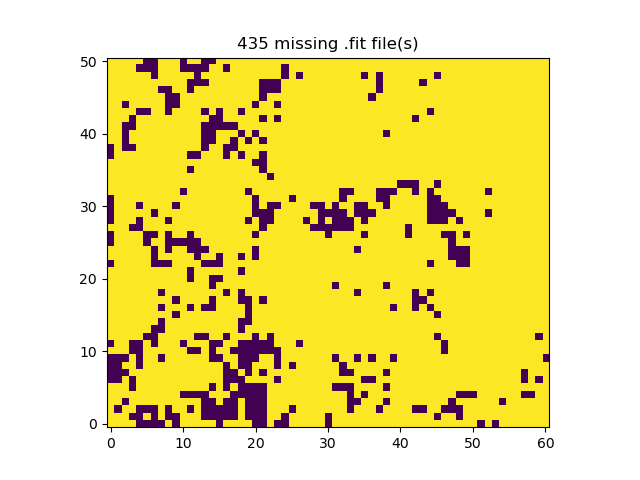

In [148]:
import matplotlib.pyplot as plt

r_smi=np.array(smi['indices'])  #.reshape((61,51))  # fast, slow
allindices = np.ones(imageindexmax+1)
np.put(allindices,r_smi,0)
fig, ax = plt.subplots()
ax.imshow(allindices.reshape((51,61)), origin='lower')  # slow, fast
ax.set_title(f'{nbmissingfiles} missing .fit file(s)')
ax.format_coord = lambda x, y: format_getimageindex_imshow(x, y, (51,61))

In [124]:
np.where(r_smi==1739)

(array([333]),)

In [84]:
smi['indices']

[4,
 5,
 6,
 7,
 9,
 15,
 17,
 18,
 19,
 20,
 21,
 23,
 24,
 30,
 38,
 49,
 51,
 53,
 64,
 65,
 67,
 69,
 70,
 71,
 74,
 75,
 76,
 77,
 78,
 80,
 81,
 82,
 85,
 91,
 106,
 108,
 109,
 110,
 113,
 116,
 123,
 124,
 126,
 127,
 128,
 130,
 133,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 147,
 155,
 159,
 164,
 165,
 167,
 168,
 169,
 170,
 171,
 185,
 196,
 197,
 199,
 200,
 202,
 203,
 204,
 216,
 217,
 221,
 230,
 232,
 237,
 254,
 255,
 256,
 257,
 258,
 260,
 261,
 262,
 263,
 264,
 265,
 268,
 277,
 279,
 282,
 292,
 293,
 294,
 300,
 301,
 302,
 306,
 308,
 315,
 319,
 321,
 323,
 324,
 325,
 326,
 336,
 337,
 338,
 343,
 358,
 362,
 365,
 366,
 367,
 369,
 382,
 383,
 384,
 389,
 399,
 401,
 402,
 422,
 423,
 425,
 427,
 428,
 429,
 442,
 443,
 444,
 446,
 448,
 459,
 460,
 465,
 481,
 483,
 484,
 485,
 488,
 489,
 490,
 492,
 503,
 504,
 506,
 507,
 511,
 513,
 520,
 526,
 544,
 549,
 550,
 551,
 553,
 556,
 563,
 564,
 567,
 568,
 569,
 572,
 574,
 580,
 583,
 585,
 